Zomato Data Analysis Project

Step 1 - Importing Libraries

pandas is used for data manipulation and analysis.
numpy is used for numerical operations.
matplotlib.pylot and seaborn are used for data visualization.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step-2 Create the data frame

In [42]:
dataframe = pd.read_csv("Zomato data .csv")

In [43]:
print(dataframe['rate'].head())

0    4.1/5
1    4.1/5
2    3.8/5
3    3.7/5
4    3.8/5
Name: rate, dtype: object


In [44]:
def handleRate(value):
    value = str(value).split('/')[0]

    if value == 'NEW' or value == '-':
        return None

    return float(value)

In [45]:
dataframe['rate'] = dataframe['rate'].apply(handleRate)

In [46]:
print(dataframe['rate'].head())

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64


In [47]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


Type of Resturant

In [48]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'type of resturant')

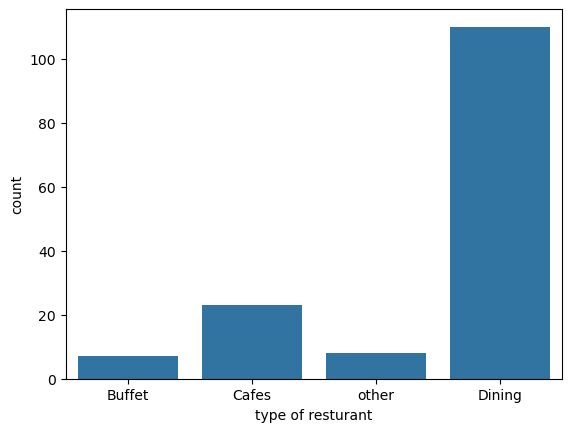

In [51]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("type of resturant")

Conclusion: The majority of the resturants fall into the dining category.


    Dining resturants are perferred by a larger number of individuals.

Text(0, 0.5, 'Votes')

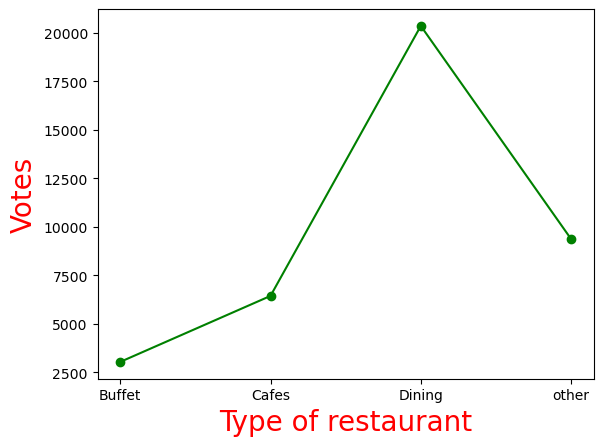

In [52]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})

plt.plot(result, c="green", marker="o")
plt.xlabel("Type of restaurant", c="red", size=20)
plt.ylabel("Votes", c="red", size=20)

Conclusion - Dining resturant has received maximum votes.

In [59]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


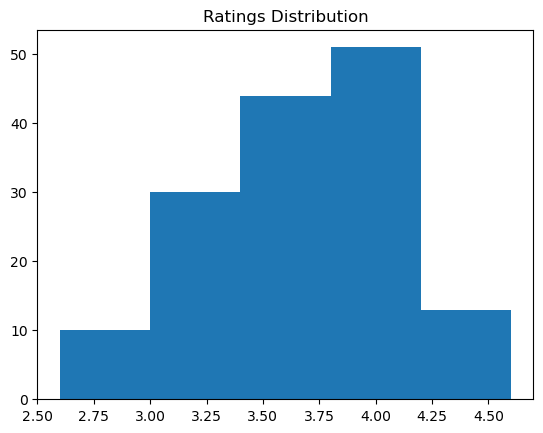

In [53]:
plt.hist(dataframe['rate'],bins=5)
plt.title("Ratings Distribution")
plt.show()

Conclusion:The majority of restaurants received ratings ranging from 3.5 to 4.

The majority of couples prefer resturants with an approximate cost of 300 rupess.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

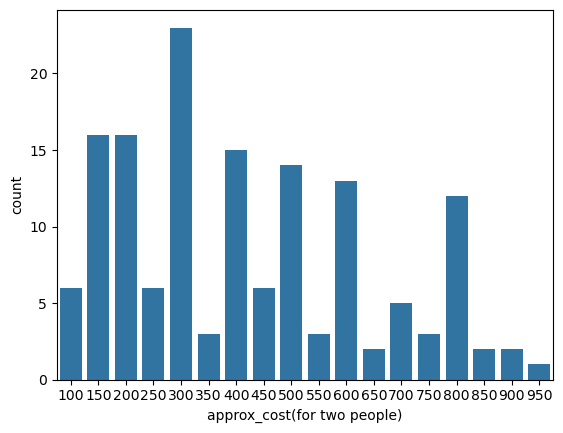

In [54]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

whether online orders receive higher ratings than offline orders.

<Axes: xlabel='online_order', ylabel='rate'>

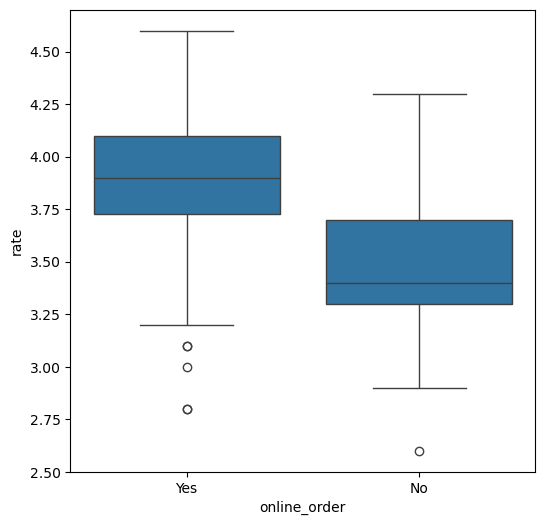

In [55]:
plt.figure(figsize = (6,6))
sns.boxplot(x= 'online_order', y = 'rate', data = dataframe)

CONCLUSION: offline orders received lower ratings in comparison to online orders, which obtained excellent ratings.

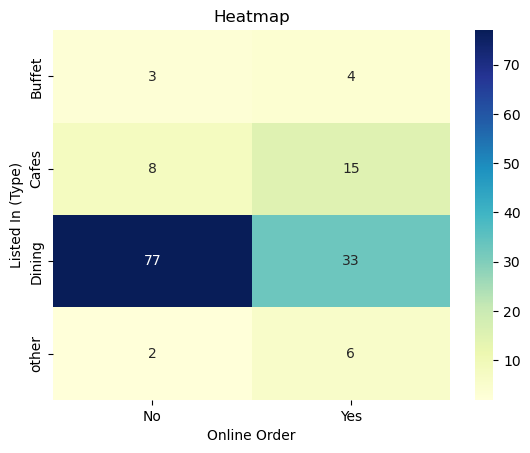

In [58]:
pivot_table = dataframe.pivot_table(
    index='listed_in(type)',
    columns='online_order',
    values='votes',
    aggfunc='count'
)

sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='.0f')

plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()

CONCLUSION : Dining restaurants primarily accept offline orders , whereas cafes primarily receive onlnie orders. 
This suggests that clients prefer to place orders in person at restaurants, but prefer online oedering at cafes.